In [2]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

In [3]:
df0 = pd.read_csv("combined_brand_reviews.csv")
df = df0.copy()
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   group     636 non-null    object
 1   title     636 non-null    object
 2   postdate  636 non-null    int64 
 3   fulltext  636 non-null    object
 4   link      636 non-null    object
dtypes: int64(1), object(4)
memory usage: 25.0+ KB


In [4]:
# 날짜 변환 및 요일/월 추출
df['postdate_dt'] = pd.to_datetime(df['postdate'].astype(str), format='%Y%m%d')
df['월'] = df['postdate_dt'].dt.month
df['요일_영문'] = df['postdate_dt'].dt.day_name()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   group        636 non-null    object        
 1   title        636 non-null    object        
 2   postdate     636 non-null    int64         
 3   fulltext     636 non-null    object        
 4   link         636 non-null    object        
 5   postdate_dt  636 non-null    datetime64[ns]
 6   월            636 non-null    int32         
 7   요일_영문        636 non-null    object        
dtypes: datetime64[ns](1), int32(1), int64(1), object(5)
memory usage: 37.4+ KB


In [5]:
# 연도 추출
df['연도'] = (df['postdate'] // 10000).astype(int)

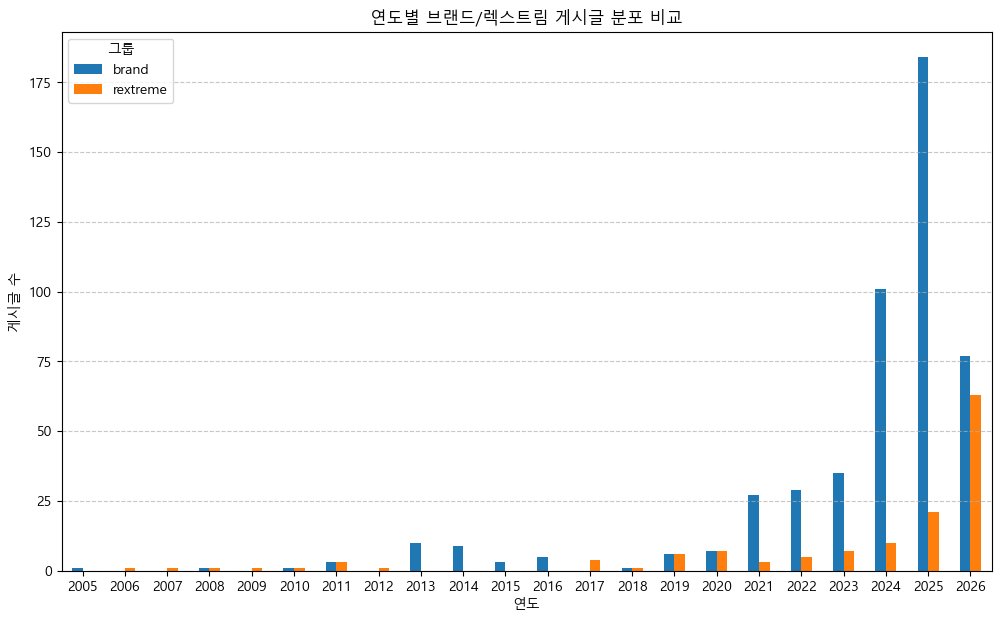

In [6]:
# 그룹별 연도 분포 시각화
# 2020년 이후의 데이터가 급증하므로 최근 트렌드 파악에 용이합니다.
yearly_group_analysis = pd.crosstab(df['연도'], df['group']).sort_index()

yearly_group_analysis.plot(kind='bar', figsize=(12, 7), rot=0)
plt.title('연도별 브랜드/렉스트림 게시글 분포 비교')
plt.xlabel('연도')
plt.ylabel('게시글 수')
plt.legend(title='그룹')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

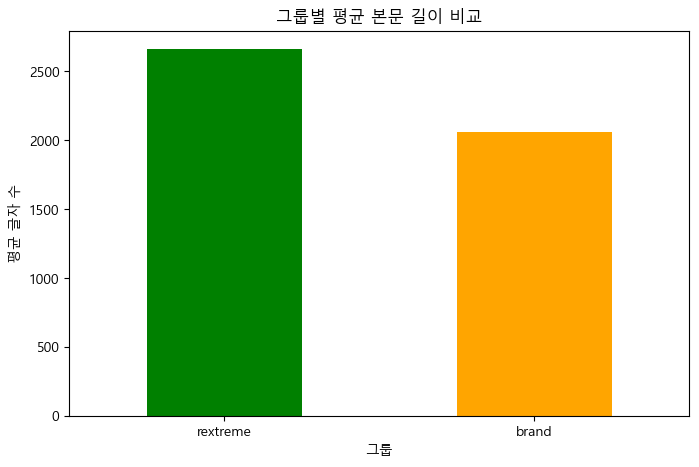

In [7]:
# 그룹별 평균 본문 길이 (정성도 측정)
df['본문길이'] = df['fulltext'].str.len()
avg_len = df.groupby('group')['본문길이'].mean().sort_values(ascending=False)
avg_len.plot(kind='bar', color=['green', 'orange'], rot=0, figsize=(8, 5))
plt.title('그룹별 평균 본문 길이 비교')
plt.xlabel('그룹')
plt.ylabel('평균 글자 수')
plt.show()

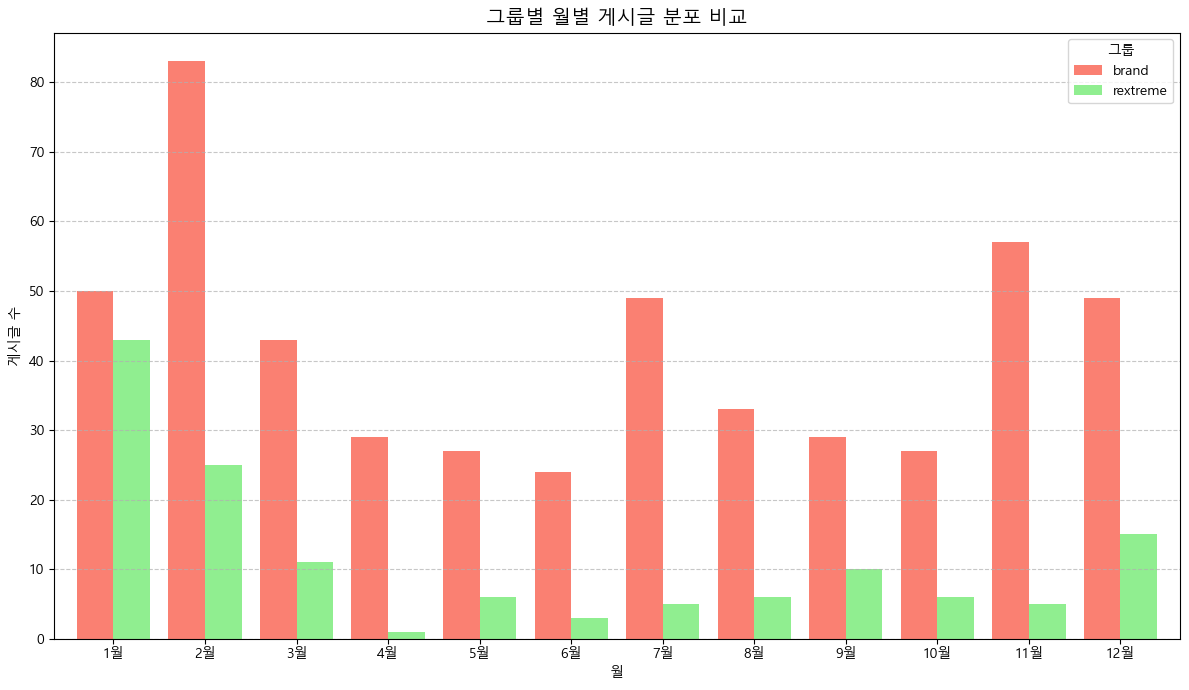

In [8]:
# 그룹별 월별 게시글 분포 비교
# 교차표(crosstab)를 생성하여 brand와 rextreme 그룹을 비교합니다.
monthly_group = pd.crosstab(df['월'], df['group']).reindex(range(1, 13), fill_value=0)

# rot=0 설정을 통해 x축 라벨(월)이 기울어지지 않게 합니다.
ax = monthly_group.plot(kind='bar', figsize=(12, 7), rot=0, width=0.8, color=['salmon', 'lightgreen'])

plt.title('그룹별 월별 게시글 분포 비교', fontsize=14)
plt.xlabel('월')
plt.ylabel('게시글 수')
plt.xticks(range(0, 12), labels=[f'{m}월' for m in range(1, 13)])
plt.legend(title='그룹')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [9]:
# 최근 1년 데이터만 살펴보기.
# 특정 기간 필터링 (2025년 3월 1일 ~ 2026년 3월 31일)
start_date = '2025-03-01'
end_date = '2026-03-31'
df_target = df[(df['postdate_dt'] >= start_date) & (df['postdate_dt'] <= end_date)].copy()

# 시각화용 '연-월' 컬럼 생성 및 정렬용 인덱스 확보
# %y-%m 형식(예: 25-03)으로 변환하여 x축 가독성을 높입니다.
df_target['연월'] = df_target['postdate_dt'].dt.strftime('%y-%m')
month_order = sorted(df_target['연월'].unique())

# 그룹별 월별 게시글 집계 (교차표)
monthly_comparison = pd.crosstab(df_target['연월'], df_target['group']).reindex(month_order, fill_value=0)

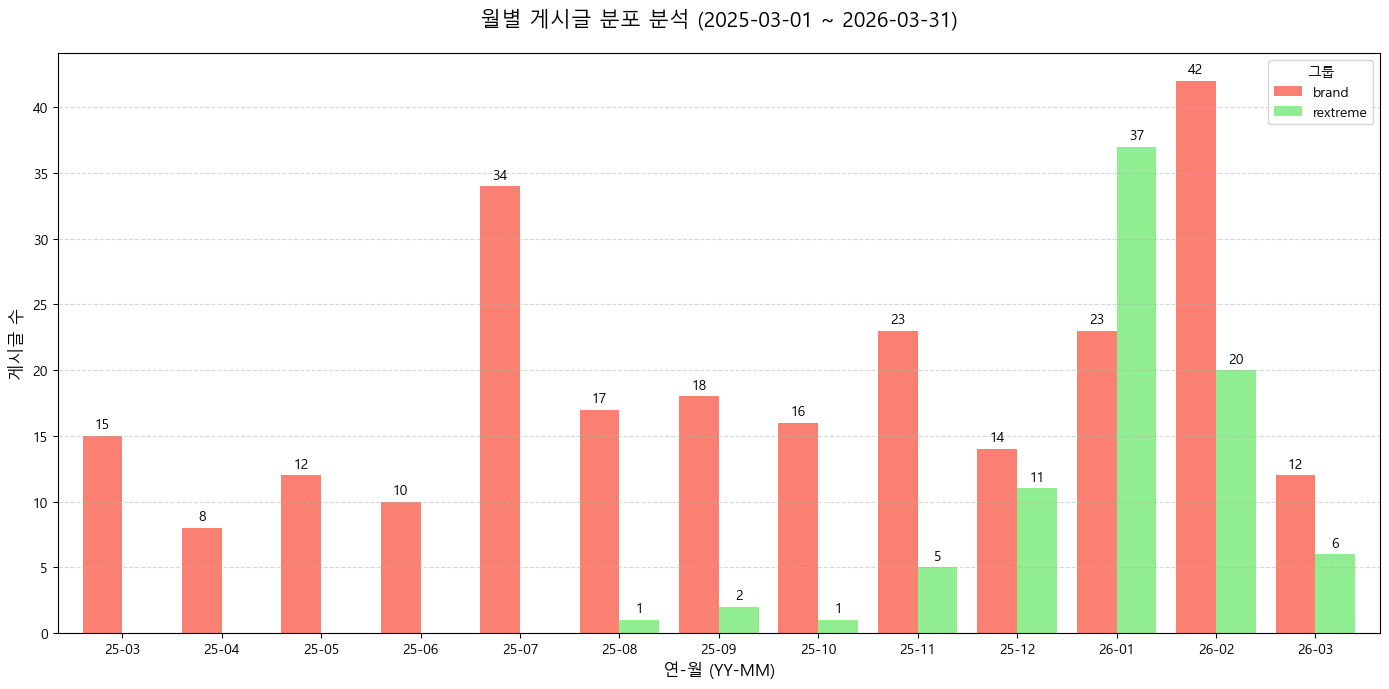

✅ 분석 기간: 2025-03-01 ~ 2026-03-31
✅ 해당 기간 총 데이터 수: 327건
group
brand       244
rextreme     83
dtype: int64


In [10]:
# 시각화
ax = monthly_comparison.plot(kind='bar', figsize=(14, 7), rot=0, width=0.8, color=['salmon', 'lightgreen'])

plt.title(f'월별 게시글 분포 분석 ({start_date} ~ {end_date})', fontsize=15, pad=20)
plt.xlabel('연-월 (YY-MM)', fontsize=12)
plt.ylabel('게시글 수', fontsize=12)
plt.legend(title='그룹', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# 막대 위에 수치 데이터 표시
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(str(int(p.get_height())), (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)

plt.tight_layout()
plt.show()

# 필터링된 결과 요약 출력
print(f"✅ 분석 기간: {start_date} ~ {end_date}")
print(f"✅ 해당 기간 총 데이터 수: {len(df_target)}건")
print(monthly_comparison.sum())